Robustness evaluation


In [10]:
# Try heatmap with relative difference (not the one to use)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

#load data
BASE_PATH = r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht"

files = {
    "original": os.path.join(BASE_PATH, "opensmile_wiener_features_pain.csv"),
    "-6 dB": os.path.join(BASE_PATH, "opensmile_intensity_-6dB_features_pain.csv"),
    "-3 dB": os.path.join(BASE_PATH, "opensmile_intensity_-3dB_features_pain.csv"),
    "+3 dB": os.path.join(BASE_PATH, "opensmile_intensity_3dB_features_pain.csv"),
    "+6 dB": os.path.join(BASE_PATH, "opensmile_intensity_6dB_features_pain.csv"),
}

# data load in dataframe 
dfs = {}
for key, path in files.items():
    df = pd.read_csv(path)
    dfs[key] = df
    print(f"{key}: shape = {df.shape}")

# control on presence of ID-kolommen
required_id_cols = ["participant_id", "filename"]

for key, df in dfs.items():
    for col in required_id_cols:
        if col not in df.columns:
            raise ValueError(f"Kolom '{col}' niet gevonden in bestand: {key}")

# data sort on participant_id and filename
for key in dfs:
    dfs[key] = dfs[key].sort_values(by=["participant_id", "filename"]).reset_index(drop=True)

# Controle of de rijen echt overeenkomen
reference_ids = dfs["original"][["participant_id", "filename"]].copy()

for key in ["-6 dB", "-3 dB", "+3 dB", "+6 dB"]:
    compare_ids = dfs[key][["participant_id", "filename"]]
    if not reference_ids.equals(compare_ids):
        raise ValueError(f"De rijen in '{key}' komen niet overeen met het originele bestand.")

exclude_cols = ["participant_id", "filename", "file_path", "name"]
numeric_cols = dfs["original"].select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

print(f"Aantal numerieke feature-kolommen: {len(feature_cols)}")


# relative difference 
epsilon = 1e-8
rel_diff_means = {}

original_features = dfs["original"][feature_cols].copy()

for condition in ["-6 dB", "-3 dB", "+3 dB", "+6 dB"]:
    perturbed_features = dfs[condition][feature_cols].copy()

    relative_difference = np.abs(perturbed_features - original_features) / (
        np.abs(original_features) + epsilon
    ) #abs(perturbed - original) / (abs(original) + epsilon)
    # mean relative difference per feature
    rel_diff_means[condition] = relative_difference.mean(axis=0)


# dataframe for heatmap 
heatmap_df = pd.DataFrame(rel_diff_means)
heatmap_df["mean_change"] = heatmap_df.mean(axis=1)
heatmap_df = heatmap_df.sort_values(by="mean_change", ascending=False)
heatmap_df = heatmap_df.drop(columns=["mean_change"])

top_n = 88
heatmap_top = heatmap_df.head(top_n)


#figure heatmap     
plt.figure(figsize=(9, 12))

sns.heatmap(
    heatmap_top,
    cmap="magma",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Gemiddelde relatieve verandering"},
    annot=False
)

plt.title("Robustness van eGeMAPS-features bij intensity-veranderingen", fontsize=14)
plt.xlabel("Intensity perturbatie", fontsize=12)
plt.ylabel("Features (gesorteerd op meest veranderd)", fontsize=12)
plt.tight_layout()
plt.show()




FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\marti\\Documents\\Technical Medicine Master\\Stages TM2\\TM2-3\\Technische opdracht\\opensmile_wiener_features_pain.csv'

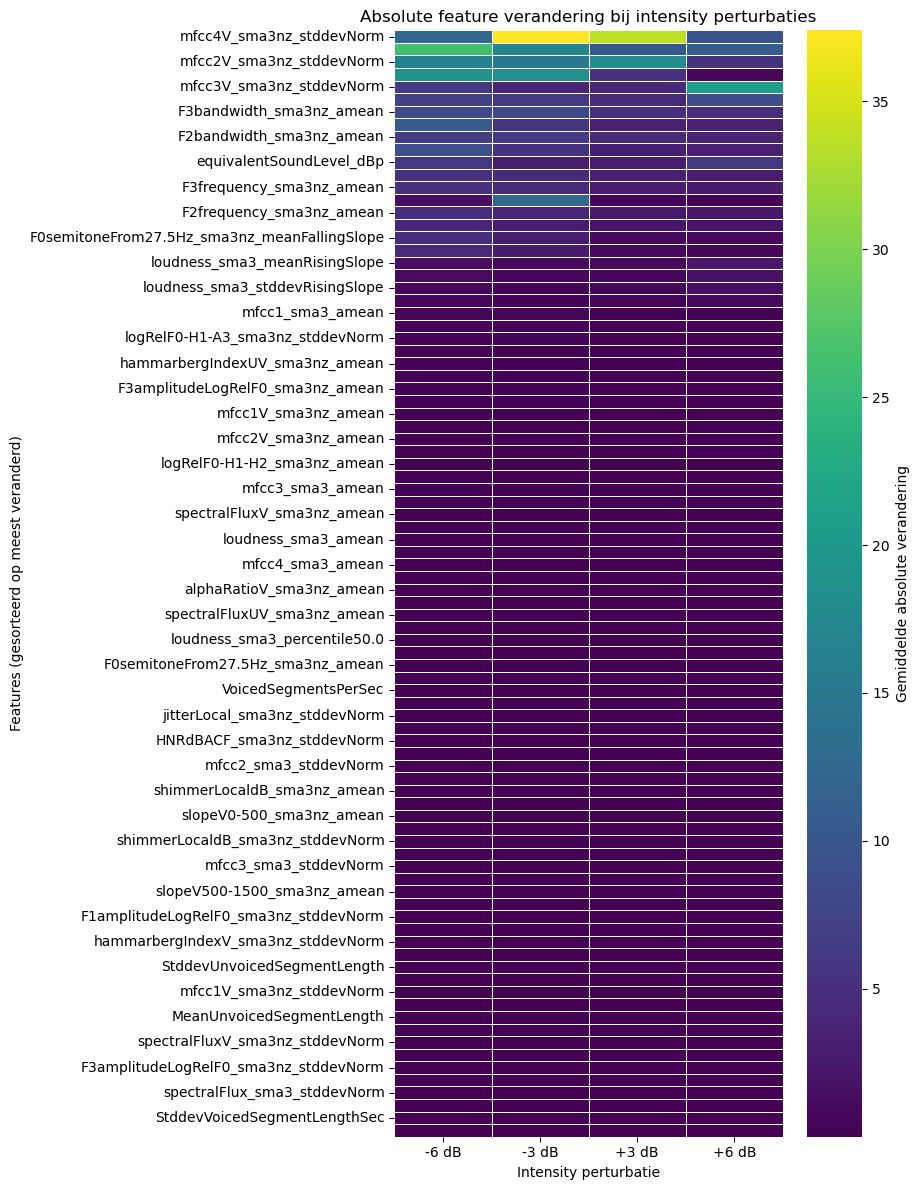

In [ ]:
# try heatmap with absolute difference (not the one to use)
BASE_PATH = r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht"

files = {
    "original": os.path.join(BASE_PATH, "opensmile_wiener_features_pain.csv"),
    "-6 dB": os.path.join(BASE_PATH, "opensmile_intensity_-6dB_features_pain.csv"),
    "-3 dB": os.path.join(BASE_PATH, "opensmile_intensity_-3dB_features_pain.csv"),
    "+3 dB": os.path.join(BASE_PATH, "opensmile_intensity_3dB_features_pain.csv"),
    "+6 dB": os.path.join(BASE_PATH, "opensmile_intensity_6dB_features_pain.csv"),
}


#load data in dataframe
dfs = {k: pd.read_csv(v) for k, v in files.items()}

for k in dfs:
    dfs[k] = dfs[k].sort_values(by=["participant_id", "filename"]).reset_index(drop=True)

reference_ids = dfs["original"][["participant_id", "filename"]]

for key in ["-6 dB", "-3 dB", "+3 dB", "+6 dB"]:
    if not reference_ids.equals(dfs[key][["participant_id", "filename"]]):
        raise ValueError(f"Mismatch in {key}")


# identification of feature columns
exclude_cols = ["participant_id", "filename", "file_path", "name"]
numeric_cols = dfs["original"].select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]


# absolute difference
abs_diff_means = {}

original_features = dfs["original"][feature_cols]

for condition in ["-6 dB", "-3 dB", "+3 dB", "+6 dB"]:
    perturbed_features = dfs[condition][feature_cols]

    abs_diff = np.abs(perturbed_features - original_features)

    abs_diff_means[condition] = abs_diff.mean(axis=0) #mean for the rows (files)


# dataframe for heatmap
heatmap_df = pd.DataFrame(abs_diff_means)

heatmap_df["mean_change"] = heatmap_df.mean(axis=1)
heatmap_df = heatmap_df.sort_values(by="mean_change", ascending=False)
heatmap_df = heatmap_df.drop(columns=["mean_change"])

top_n = 88
heatmap_top = heatmap_df.head(top_n)


# heatmap
plt.figure(figsize=(9, 12))

sns.heatmap(
    heatmap_top,
    cmap="viridis",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Gemiddelde absolute verandering"},
    annot=False
)

plt.title("Absolute feature verandering bij intensity perturbaties")
plt.xlabel("Intensity perturbatie")
plt.ylabel("Features (gesorteerd op meest veranderd)")
plt.tight_layout()
plt.show()


Robustness evaluation with standardisation on Wiener Filtered audio, with StandardScaler (the one to use)

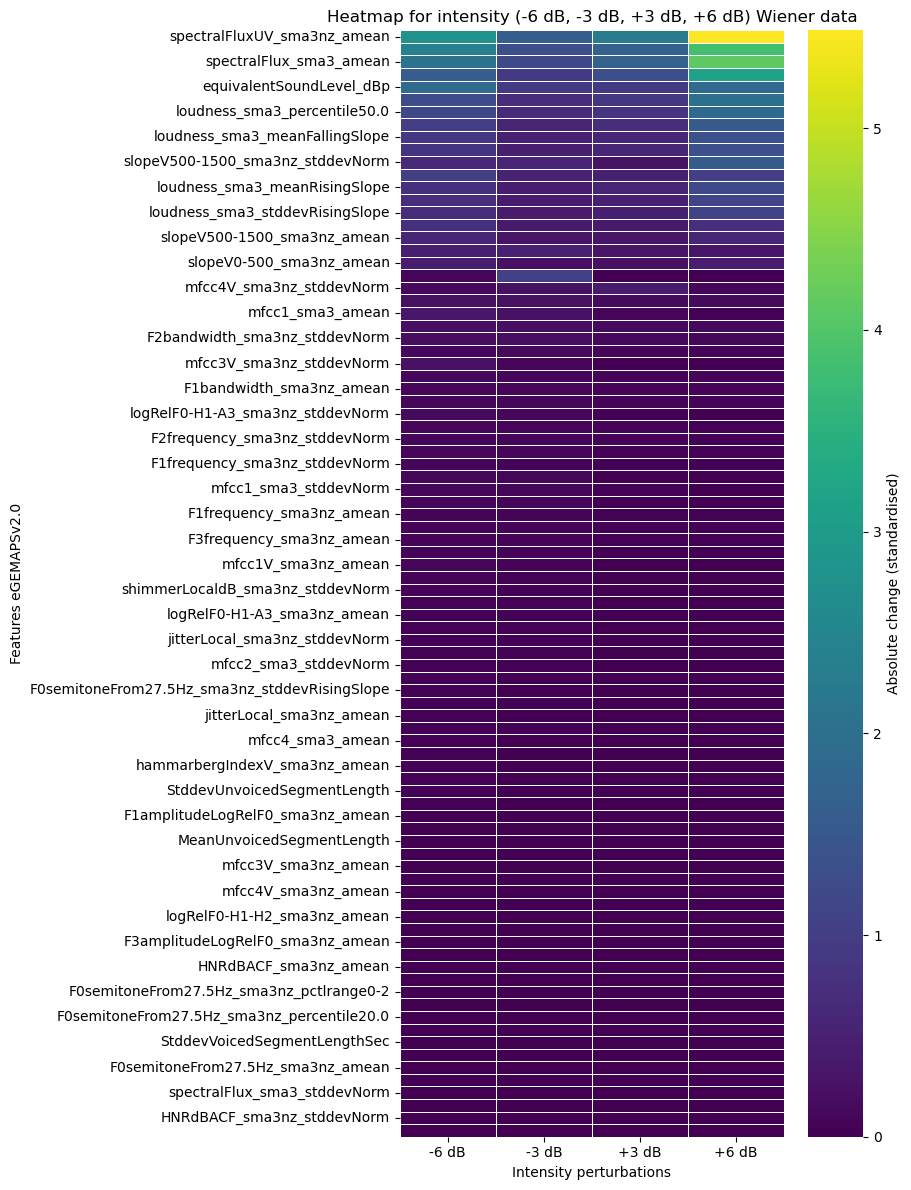

In [13]:
BASE_PATH = r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht"

files = {
    "original": os.path.join(BASE_PATH, "opensmile_wiener_features_pain.csv"),
    "-6 dB": os.path.join(BASE_PATH, "opensmile_intensity_-6dB_features_pain.csv"),
    "-3 dB": os.path.join(BASE_PATH, "opensmile_intensity_-3dB_features_pain.csv"),
    "+3 dB": os.path.join(BASE_PATH, "opensmile_intensity_3dB_features_pain.csv"),
    "+6 dB": os.path.join(BASE_PATH, "opensmile_intensity_6dB_features_pain.csv"),
}

# data
dfs = {k: pd.read_csv(v) for k, v in files.items()}

for k in dfs:
    dfs[k] = dfs[k].sort_values(by=["participant_id", "filename"]).reset_index(drop=True)

reference_ids = dfs["original"][["participant_id", "filename"]]

for key in ["-6 dB", "-3 dB", "+3 dB", "+6 dB"]:
    if not reference_ids.equals(dfs[key][["participant_id", "filename"]]):
        raise ValueError(f"Mismatch in {key}")

# features
exclude_cols = ["participant_id", "filename", "file_path", "name"]
numeric_cols = dfs["original"].select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

#standardisation with sklearn
# fit the scaler on the original data
scaler = StandardScaler()
scaler.fit(dfs["original"][feature_cols])
dfs_std = {}

for key, df in dfs.items():
    df_std = df.copy()
    df_std_features = scaler.transform(df[feature_cols]) # apply the same transformation also to the perturbated data (-3 dB, +3 dB, etc.)
    df_std[feature_cols] = df_std_features
    dfs_std[key] = df_std

# Absolute difference with standardised features
abs_diff_means = {}
original_features = dfs_std["original"][feature_cols]

for condition in ["-6 dB", "-3 dB", "+3 dB", "+6 dB"]:
    perturbed_features = dfs_std[condition][feature_cols]

    abs_diff = np.abs(perturbed_features - original_features)
    abs_diff_means[condition] = abs_diff.mean(axis=0)

# heatmap
heatmap_df = pd.DataFrame(abs_diff_means)

heatmap_df["mean_change"] = heatmap_df.mean(axis=1)
heatmap_df = heatmap_df.sort_values(by="mean_change", ascending=False)
heatmap_df = heatmap_df.drop(columns=["mean_change"])

top_n = 88  # all features
heatmap_top = heatmap_df.head(top_n)

plt.figure(figsize=(9, 12))
sns.heatmap(
    heatmap_top,
    cmap="viridis",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Absolute change (standardised)"},
    annot=False
)

plt.title("Heatmap for intensity (-6 dB, -3 dB, +3 dB, +6 dB) Wiener data")
plt.xlabel("Intensity perturbations")
plt.ylabel("Features eGEMAPSv2.0")
plt.tight_layout()
plt.show()